In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from collections import Counter
import scipy.stats as ss
import matplotlib.dates as mpldates

%matplotlib inline
import pymc
import arviz as az
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

import warnings

warnings.filterwarnings(
    "ignore",
    module="arviz.stats.density_utils",
)
warnings.filterwarnings(
    "ignore",
    message="Could not infer format",
    category=UserWarning,
)
warnings.filterwarnings("ignore", message=".*BLAS.*")

## Full Data Set (Originally Downloaded Nov 13, 2025)
lacrime = pd.read_csv("../axproj/Crime_Data_from_2020_to_Present.csv", 
                 low_memory =False,
                 parse_dates = ["Date Rptd", "DATE OCC"]
                 ) ## Full Data Set

## Metadata from LACity.org 
MO_Codes = pd.read_csv("../axproj/MO_Codes_Numerical.csv")  ## Modus Operandi codes
MO_Codes = MO_Codes.rename(columns={'MO_code' : 'MO_Code', 'MO_desc' : 'MO_Desc'})
MO_Codes['MO_Code'] = MO_Codes['MO_Code'].astype('Int64').astype(str).str.zfill(4)

map_desc = dict( ## meta_data map for victim descent
    A="Other Asian", B="Black", C="Chinese", D="Cambodian",
    F="Filipino", G="Guamanian", H="Hispanic/Latin/Mexican",
    I="American Indian/Alaskan Native", J="Japanese", K="Korean",
    L="Laotian", O="Other", P="Pacific Islander", S="Samoan",
    U="Hawaiian", V="Vietnamese", W="White", X="Unknown",
    Z="Asian Indian"
)


# clean up function
def clean_lacrime(df):
    df = df.copy() 

    # df['DATE OCC']  = pd.to_datetime(df['DATE OCC'],  format="%m/%d/%Y", errors="coerce")
    # df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format="%m/%d/%Y", errors="coerce")

    df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4) # standardize time
    df['hour'] = df['TIME OCC'].str[:2].astype(int)
    df['minute'] = df['TIME OCC'].str[2:].astype(int)
    df['time_float'] = df['hour'] + df['minute']/60.0
    df['month'] = df['DATE OCC'].dt.month
    df['day'] = df['DATE OCC'].dt.day
    df['year'] = df['DATE OCC'].dt.year
    # df['week_of_year'] = df['DATE OCC'].dt.isocalendar().week
 
    df['loc_missing'] = ((df['LAT'] == 0) & (df['LON'] == 0)).astype(int) # missing loc indicator
    df['Vict Age'] = df['Vict Age'].replace(0, np.nan) # clean missing age victim

    df['LAT_std'] = (df['LAT'] - df['LAT'].mean()) / df['LAT'].std() # standardize location
    df['LON_std'] = (df['LON'] - df['LON'].mean()) / df['LON'].std()

    # deal with blanks in weapon codes and mocodes
    df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0)
    df['Weapon Desc'] = df['Weapon Desc'].fillna("n/a")
    
    # fill in empty mocodes with 0000 instead of 'na'
    df['Mocodes'] = df['Mocodes'].fillna("0000") 
    
    # removing spaces from some variables
    df['AREA'] = df['AREA NAME']
    df['vDescent'] = df['Vict Descent']

    # add a sequential month and sequential year
    df['month_seq'] = (df['year'] - df['year'].min()) * 12 + df['month']
    df['week_seq'] = ((df['DATE OCC'] - df['DATE OCC'].min()).dt.days // 7) + 1

    return df

# potential regression targets
def add_regression_vars(df):
    df = df.copy()
    df['report_delay'] = (df['Date Rptd'] - df['DATE OCC']).dt.days # delay in reporting
    df['weapon_cd'] = df['Weapon Used Cd'].fillna(0) # fill in 0s when weapon code is n
    df['severity'] = 3 - (df['Part 1-2'] + np.where(df['weapon_cd'] > 0, -1, 0)) # 1,2,3 severity scale based on weapon usage and Part 1-2
    df['area_score'] = df.groupby(['AREA', 'DATE OCC']).transform('size') # count per area per day , use transform to index correctly
    df['complexity'] = df[['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']].notnull().sum(axis = 1) # crime complexity based on number of codes
    return df

def series_center(series):
    return series - series.mean()
def series_center_z(series):
    return (series - series.mean())/(series.std())


def plotQQ(series):
    fig, ax = plt.subplots(figsize=(8, 8))
    ss.probplot(series, plot=ax)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_ylim(series.min(), series.max())


def clean_nan(df):
    cols = ['Vict Age', 'Premis Desc', 'Status']
    df = df.dropna(subset=cols)
    df = df[df['DATE OCC'].dt.year < 2024]
    return df

# convert sequential week back to a date
def week_seq_to_date(week_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    days_diff = (week_seq - 1) * 7
    return start_date + timedelta(days = days_diff)

def month_seq_to_date(month_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    return start_date + relativedelta(months = month_seq - 1)  


lacrime = clean_lacrime(lacrime)
lacrime = clean_nan(lacrime)
lacrime = add_regression_vars(lacrime)
# create dataframe of weapon usage
distinct_weapons = lacrime[['weapon_cd', 'Weapon Desc']].drop_duplicates()

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### 4.2 Compositional Shift in Crime

We've seen that the number of Severity 2 (most common) crimes increased after a certain switchpoint in Los Angeles. Severity 2 however is a wide berth of crime by our definition, including weapon-involved Part 2 crimes, and unarmed Part 1 crimes. 

Let's investigate the composition of crimes. Once again thinking about lockdowns, when more people are trapped at home, crimes involving strangers or vehicles will be more rare. Our data set includes modus operandi codes, and also crime codes, with crime code descriptions. There are a few questions we could potentially answer: How prevalent are violent crimes in different areas (or other drivers)? How has the composition of crime changed over time? 

#### 4.2.1 Additional EDA
We perform some additional EDA that wasn't covered in the original scope, because this data is text. We don't have all the tools for text categorization, so we will handle this manually to the best of our ability.

In [2]:
lacrime['Mocodes'] = lacrime['Mocodes'].astype(str)
lacrime['MO_list'] = lacrime['Mocodes'].str.split()
lacrime['MO_list'] = lacrime['MO_list'].apply(lambda xs: [x for x in xs if x != '0000'])
crime_mo = lacrime.explode('MO_list').rename(columns = {'MO_list': 'MO_Code'})
crime_mo = crime_mo.dropna(subset = ['MO_Code'])
crime_mo = crime_mo.merge(MO_Codes, how = 'left', on = 'MO_Code')

In [3]:
crime_mo[['DR_NO', 'DATE OCC', 'AREA', 'Crm Cd', 'Crm Cd Desc', 'MO_Code', 'MO_Desc']].sample(10)


,DR_NO,DATE OCC,AREA,Crm Cd,Crm Cd Desc,MO_Code,MO_Desc
1526769,221007141,2022-03-24,West Valley,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1402,Evidence Booked (any crime)
2095642,230305486,2023-01-28,Southwest,440,THEFT PLAIN - PETTY ($950 & UNDER),0344,Removes vict property
2113409,231204814,2023-01-15,77th Street,888,TRESPASSING,0554,Suspect is Victim's Brother
2064024,231311463,2023-05-27,Newton,352,PICKPOCKET,0344,Removes vict property
657689,211014472,2021-11-11,West Valley,626,INTIMATE PARTNER - SIMPLE ASSAULT,1202,Aged (60 & over) or blind/crippled/unable to c...
1598350,220321815,2022-12-13,Southwest,930,CRIMINAL THREATS - NO WEAPON DISPLAYED,1251,Victim was a student
1795289,230119414,2023-09-06,Central,330,BURGLARY FROM VEHICLE,1300,Vehicle involved
1355695,221310863,2022-05-08,Newton,901,VIOLATION OF RESTRAINING ORDER,2004,Suspect is homeless/transient
437476,200309662,2020-04-09,Southwest,410,"BURGLARY FROM VEHICLE, ATTEMPTED",1309,Susp uses vehicle
615271,210806503,2021-03-02,West LA,310,BURGLARY,1606,Open/unlocked


In [4]:
# example_drno = crime_mo.groupby('DR_NO')['MO_Code'].nunique().loc[lambda s: s > 5].sample(1).index[0]
example_drno = 231809796
crime_mo[crime_mo['DR_NO'] == example_drno][['DR_NO', 'Mocodes', 'MO_Code', 'MO_Desc', 'Crm Cd Desc', 'severity']]

,DR_NO,Mocodes,MO_Code,MO_Desc,Crm Cd Desc,severity
2300578,231809796,0329 2000 0913 1813 0444 1821 1241 0319,0329,Vandalized,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300579,231809796,0329 2000 0913 1813 0444 1821 1241 0319,2000,Domestic violence,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300580,231809796,0329 2000 0913 1813 0444 1821 1241 0319,0913,Victim knew Suspect,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300581,231809796,0329 2000 0913 1813 0444 1821 1241 0319,1813,Susp is/was current/former spouse/co-habitant,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300582,231809796,0329 2000 0913 1813 0444 1821 1241 0319,0444,Pushed,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300583,231809796,0329 2000 0913 1813 0444 1821 1241 0319,1821,Spouse,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300584,231809796,0329 2000 0913 1813 0444 1821 1241 0319,1241,Spouse,INTIMATE PARTNER - SIMPLE ASSAULT,2
2300585,231809796,0329 2000 0913 1813 0444 1821 1241 0319,0319,Profanity Used,INTIMATE PARTNER - SIMPLE ASSAULT,2


In [5]:
crime_mo.groupby('DR_NO')['MO_Code'].nunique().value_counts().sort_index()

MO_Code
1      98779
2     142777
3     123857
4      97964
5      73461
6      48020
7      29969
8      17295
9      10095
10     11316
Name: count, dtype: int64

In [6]:
crime_mo['MO_Desc'].value_counts().head(10)

MO_Desc
Stranger                                           255948
Removes vict property                              221074
Victim knew Suspect                                137826
Hit-Hit w/ weapon                                  109471
Vandalized                                          91195
Vehicle involved                                    78000
Domestic violence                                   68596
Force used                                          64570
Susp is/was current/former boyfriend/girlfriend     43945
Evidence Booked (any crime)                         41563
Name: count, dtype: int64

Taking a quick look at MO codes, we find that this is a catch-all description of crimes. Crimes can have multiple MO codes, from one to ten. An example above shows a case of domestic violence with 8 MO codes, including violence, victim being a spouse of the suspect, and use of profanity. Categorically, this is a rather miscellaneous assortment of descriptors. In subsequent steps, we may try to pick out certain attributes, but for a first analysis, we will instead switch over to using `Crm Cd Desc` which only 136 unique values, and is much more focused.

In [7]:
ccds = lacrime['Crm Cd Desc'].value_counts().reset_index() # Crime Code DescriptionS
ccds

,Crm Cd Desc,count
0,BATTERY - SIMPLE ASSAULT,68536
1,THEFT OF IDENTITY,55201
2,BURGLARY FROM VEHICLE,52374
3,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",47949
4,INTIMATE PARTNER - SIMPLE ASSAULT,43278
...,...,...
131,FIREARMS RESTRAINING ORDER (FIREARMS RO),2
132,LYNCHING,2
133,LYNCHING - ATTEMPTED,1
134,DISHONEST EMPLOYEE ATTEMPTED THEFT,1


In [8]:
ccds.head(10)

,Crm Cd Desc,count
0,BATTERY - SIMPLE ASSAULT,68536
1,THEFT OF IDENTITY,55201
2,BURGLARY FROM VEHICLE,52374
3,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",47949
4,INTIMATE PARTNER - SIMPLE ASSAULT,43278
5,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",40025
6,THEFT PLAIN - PETTY ($950 & UNDER),39053
7,BURGLARY,36659
8,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,29688
9,ROBBERY,23827


Unfortunately, this is text data without clear indications of categorization. We will approach this manually be repeatedly selecting a keyword from the top appearing crime and moving down the list. For example, we will categorize all "Battery" crimes together, then next "Identity" , and then "Burglary." Although not perfect, a handful of keywords should capture the majority of crimes, and we can discard or group the remaining data.

Note that the order matters, like in a SQL case statement. I've chosen to separate "identity" first, as identity theft seems unique to petty theft or vehicular theft. This is a rather manual process, but after some simple trial and error, we can capture over 90% of all crimes with some simple categorization.

In [9]:
def kws(keyword, df = ccds, col_index = 0): # keyword search
    # keyword_list.append(keyword)
    return df[df.iloc[:, col_index].str.contains(keyword, case=False, na=False)].drop_duplicates()

keywordlist = []
keywordlist.append('battery')
keywordlist.append('identity')
keywordlist.append('burglary')
keywordlist.append('assault')
keywordlist.append('vandalism')
keywordlist.append('theft')
keywordlist.append('robbery')
keywordlist.append('threat') 
keywordlist.append('brandish')    # threat
keywordlist.append('shots')       # threat
keywordlist.append('violation') 
keywordlist.append('contempt')    # violation
keywordlist.append('trespass')
keywordlist.append('stole')       # theft
keywordlist.append('pickpock')    # robbery
keywordlist.append('lewd')
keywordlist.append('extort')      # threat
keywordlist.append('indecent')    # lewd
keywordlist.append('other')
keywordlist.append('disturb')     # threat
keywordlist.append('rape')        # most severe
keywordlist.append('homicide')    # most severe
keywordlist.append('sexual')      # most severe, after ruling out batterye
keywordlist.append('traffick')    # most severe
# keywordlist.append()
covered_idx = pd.Index([])

for kw in keywordlist:
    covered_idx = covered_idx.union(kws(kw).index)
leftover = ccds.loc[~ccds.index.isin(covered_idx)]
pct_leftover = 100 * leftover['count'].sum() / ccds['count'].sum()
leftover.head(15), print(f"Leftover crimes: {leftover['count'].sum():,} ({pct_leftover:.2f}%)")

# kw_summary(keywordlist).head()

Leftover crimes: 12,702 (1.93%)


(                                          Crm Cd Desc  count
 37  CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...   1684
 41                                              ARSON   1378
 45  SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...    995
 46                     CHILD ANNOYING (17YRS & UNDER)    970
 47                     CHILD NEGLECT (SEE 300 W.I.C.)    871
 51                                    ORAL COPULATION    682
 52                                         KIDNAPPING    651
 53                  THROWING OBJECT AT MOVING VEHICLE    646
 56                                           STALKING    620
 62                       UNAUTHORIZED COMPUTER ACCESS    446
 65                                     CHILD STEALING    352
 67                                   FAILURE TO YIELD    348
 68                                        PEEPING TOM    336
 69                                 FALSE IMPRISONMENT    313
 72                                     BUNCO, ATTEMPT    263,
 None)

Our manual categorization captured 97.7% of all reported crimes. What's remaining are some bizarre minor crimes (unauthorized computer access, failure to yield), specific versions of other listed offenses, and other crimes with very low rates. At this point we are comfortable dropping what's leftover and categorizing what's been called out in our list of keywords above. If a comment is present, it represents where the crime should be categorized, so 'robbery' is categorized as itself, while pickpocketing is also categorized as robbery.

The following function takes in a list of keywords and displays all the matches, which we can use to check that our keywording has the right effect. For example, we will dismiss 'Other' as a category, as `Crm Cd Desc == OTHER ASSAULT` is already covered by 'assault' and `VEHICLE, STOLEN - OTHER` is covered by 'stole.'

Below, we will categorize crimes based on our manual data discovery.

In [10]:
# define a function that takes in a keyword or list of keywords, 
# and then returns what % of total crimes they are, as well as a few examples
def kw_summary(keywords, df=ccds, col_index=0):
    if isinstance(keywords, str):
        keywords = [keywords]
    idx = pd.Index([])
    for kw in keywords:
        idx = idx.union(df[df.iloc[:, col_index].str.contains(kw, case=False, na=False)].index)
    subset = df.loc[df.index.isin(idx)]
    total = subset['count'].sum()
    pct = 100 * total / df['count'].sum()
    print(f"{total:,} crimes ({pct:.2f}%)")
    return subset

# kw_summary(keywordlist).head()
# kw_summary(['threat','brand'])
# kw_summary('threat')
kw_summary('sex')

7,169 crimes (1.09%)


,Crm Cd Desc,count
26,BATTERY WITH SEXUAL CONTACT,3850
43,SEXUAL PENETRATION W/FOREIGN OBJECT,1254
45,"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...",995
60,SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO...,498
64,HUMAN TRAFFICKING - COMMERCIAL SEX ACTS,387
79,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,176
119,INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES),5
124,"BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT...",4


In [11]:
ccds.loc[ccds['Crm Cd Desc'].str.startswith('SEX,UNLAWFUL(INC MUTU'), 'Crm Cd Desc'].iloc[0]


'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ'

In [12]:
keyword_map = [ 
    # note that the order matters in our categorize_desc function
    # this keyword map matches the order we initially used to analyze the data
    ('battery',   'battery'),
    ('identity',  'identity'),
    ('burglary',  'burglary'),
    ('assault',   'assault'),
    ('vandalism', 'vandalism'),
    ('theft',     'theft'),
    ('robbery',   'robbery'),

    ('threat',    'threat'),
    ('brandish',  'threat'),
    ('shots',     'threat'),

    ('violation', 'violation'),
    ('contempt',  'violation'),
    ('trespass',  'violation'),

    ('stole',     'theft'),
    ('pickpock',  'robbery'),

    ('lewd',      'lewd'),
    ('extort',    'threat'),
    ('indecent',  'lewd'),

    ('other',     'other'),
    ('disturb',   'threat'),

    ('rape',      'extreme'),
    ('homicide',  'extreme'),
    ('sexual' ,   'extreme'),
    ('traffick',  'extreme')
]


def categorize_desc(desc, keyword_map = keyword_map):
    if pd.isna(desc):
        return 'other'
    
    desc = desc.lower()

    for kw, category in keyword_map:
        if kw in desc:
            return category
    return 'other'


lacrime['crm_cat'] = lacrime['Crm Cd Desc'].apply(categorize_desc, keyword_map=keyword_map)

crimecomp = lacrime.copy() # make a copy as we will drop certain categories
crimecomp = crimecomp[crimecomp['crm_cat'] != 'other']

crimecomp['crm_cat'].value_counts(dropna=False)


crm_cat
theft        141605
assault      110863
burglary      92200
battery       73193
vandalism     58261
identity      55201
threat        36430
robbery       30225
violation     27464
lewd           8962
extreme        7545
Name: count, dtype: int64

We've categorized all the crimes under 12 categories. At this point, "other" is a very broad category, but less than 2% of total crimes, which we will discard, as it includes crimes of different type, severity, etc. We want to answer the question of how crime composition changed over time through the observation period.

#### 4.2.2 Visualizations of crime composition

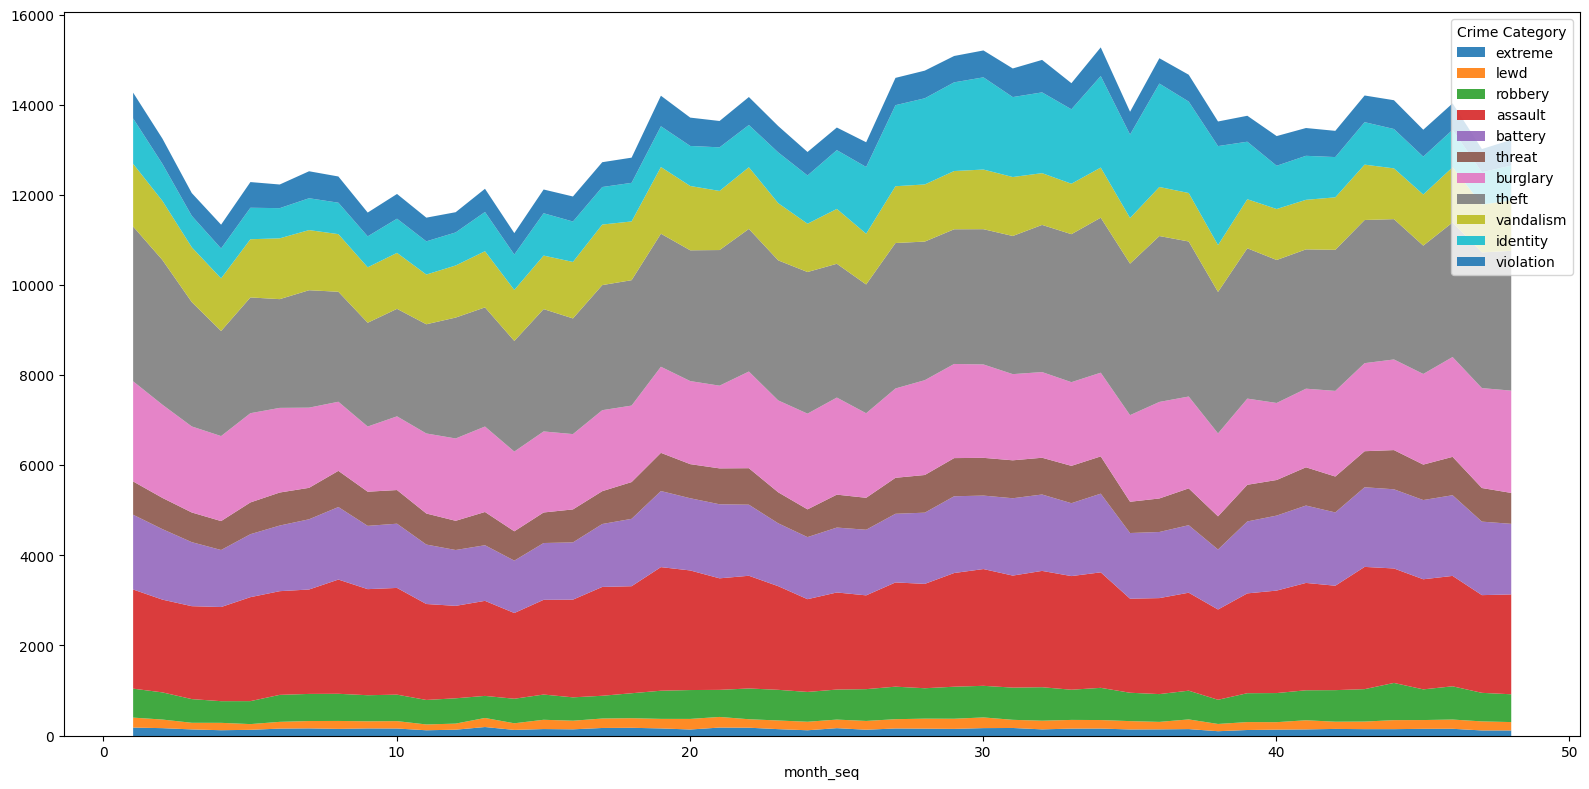

In [13]:
# crime comp by month
ccmonth = crimecomp.groupby(['month_seq', 'crm_cat']).size().reset_index(name = 'count')
ccmonthwide = ccmonth.pivot(index = 'month_seq', columns = 'crm_cat', values = 'count').fillna(0).sort_index()
cat_order = [
    'extreme',    'lewd',    'robbery',
    'assault',    'battery',    'threat',
    'burglary',    'theft',    'vandalism',
    'identity',    'violation']
ccmonthwide = ccmonthwide[cat_order]

fig, ax = plt.subplots(figsize=(16, 8))
_ = ccmonthwide.plot.area(stacked = True, linewidth = 0, alpha = 0.9, ax = ax)
plt.legend(title = 'Crime Category', loc = 'upper right')
plt.tight_layout()
plt.show()


Further grouping: Scaling makes this data relatively difficult to comprehend. In this sense, we should continue to group data slightly more. 

We will group together threats and assault. 
* Battery is defined as actual physical contact while assault is attempted or threats of physical violence. Battery and assault are commonly grouped, so we will include threats, assault, and battery under one category 'Battery and Assault'. 
* Robbery, theft, and burglary all involve stolen property or attempted stolen property. Theft is the most broad - only property loss. Burglary is unlawful entry and invasion of space with intent to commit a crime (usually theft). Finally, robbery is theft with force. For our purpose, we will combine all three into "theft." 
* Vandalism, lewd acts, and violations are relatively minor crimes, which we will group together as "minor". 

In [14]:
keyword_map_depth2 = [
    ('battery'  , 'battery and assault'),
    ('assault'  , 'battery and assault'),
    ('threat'   , 'battery and assault'),
    ('robbery'  , 'theft'),
    ('theft'    , 'theft'),
    ('burglary' , 'theft'), 
    ('vandalism', 'minor'),
    ('lewd'     , 'minor'),
    ('violation', 'minor'), 
    ('identity' , 'identity'),
    ('extreme'  , 'extreme')
]

keyword_map_depth2_dict = dict(keyword_map_depth2)

crimecomp['crm_cat2'] = crimecomp['crm_cat'].map(keyword_map_depth2_dict)
crimecomp['crm_cat2'].value_counts(dropna=False)

crm_cat2
theft                  264030
battery and assault    220486
minor                   94687
identity                55201
extreme                  7545
Name: count, dtype: int64

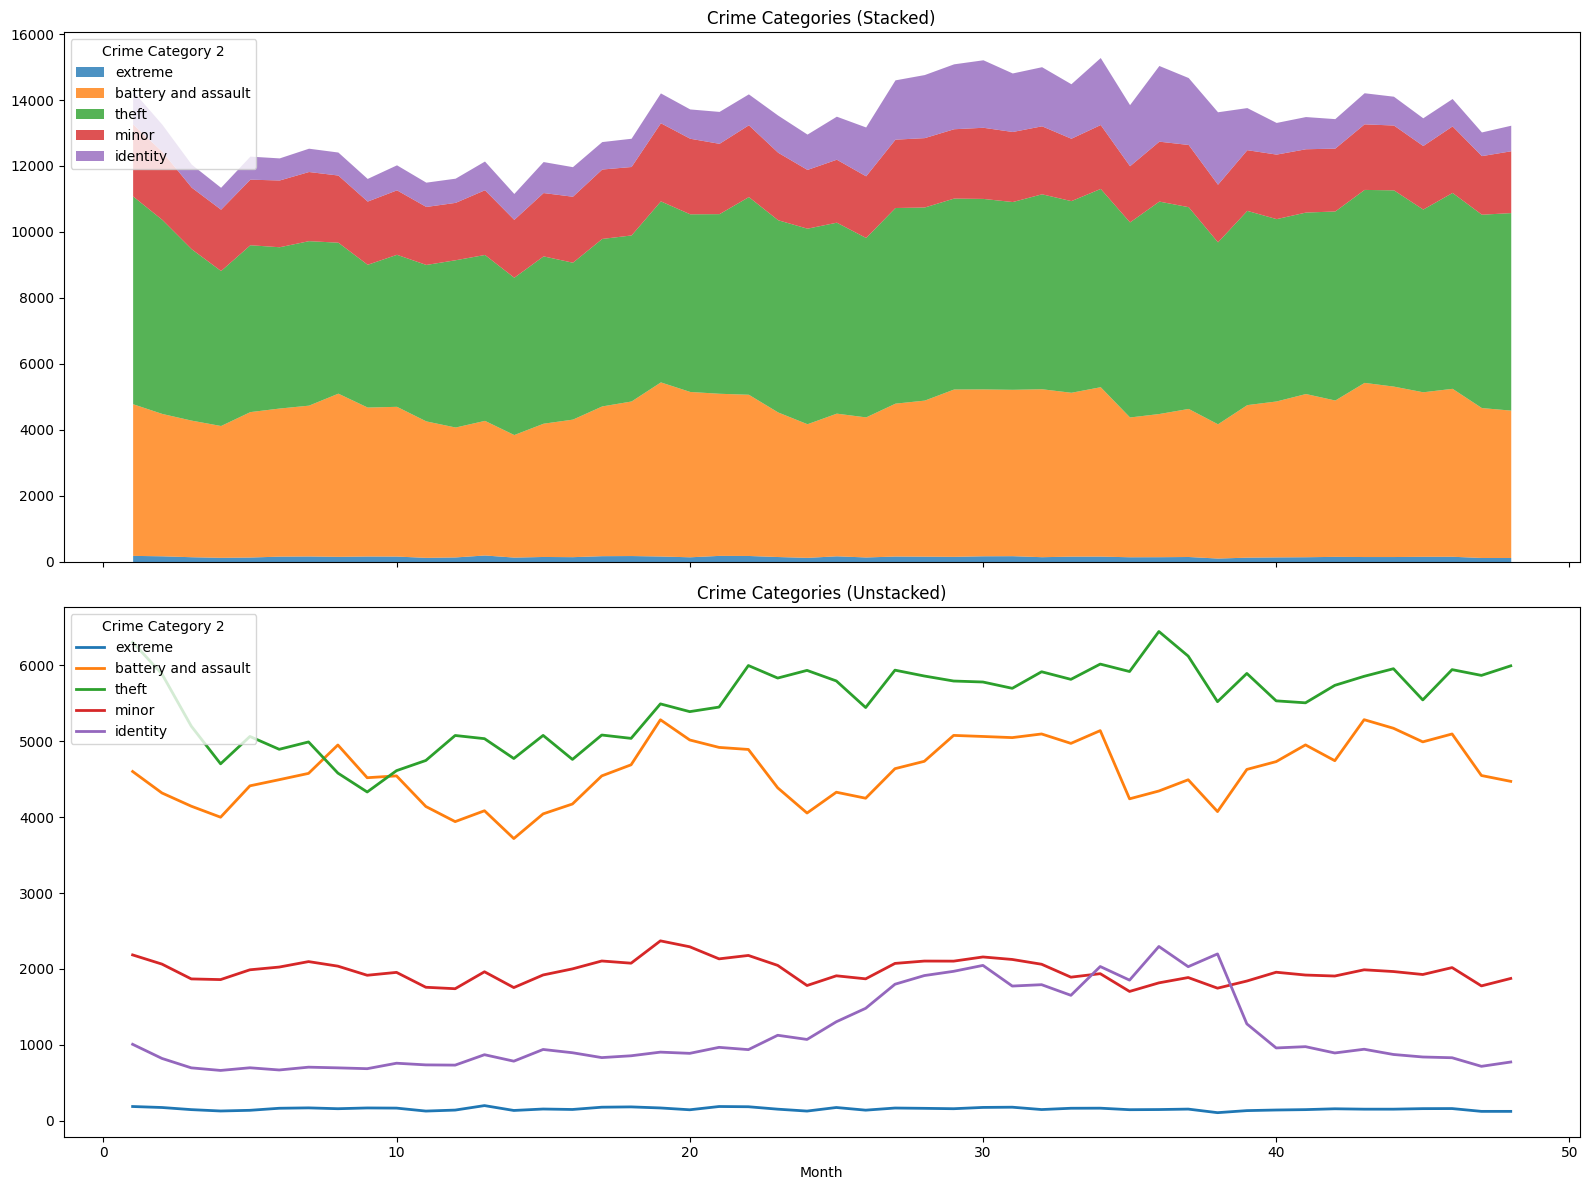

In [ ]:
ccmonth2 = crimecomp.groupby(['month_seq', 'crm_cat2']).size().reset_index(name = 'count')
ccmonth2wide = ccmonth2.pivot(index = 'month_seq', columns = 'crm_cat2', values = 'count').fillna(0).sort_index()
cat_order = ['extreme', 'battery and assault', 'theft', 'minor', 'identity']
ccmonth2wide = ccmonth2wide[cat_order]

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 12), sharex=True)

ccmonth2wide.plot.area(ax=ax1, stacked=True, linewidth=0, alpha=0.8)
ax1.set_title('Crime Categories (Stacked)')
ax1.legend(title='Crime Category 2', loc='upper left')

ccmonth2wide.plot(ax=ax2, stacked = False, linewidth = 2, alpha = 1)
ax2.set_title('Crime Categories (Unstacked)')
ax2.legend(title='Crime Category 2', loc='upper left')

ax2.set_xlabel('Month')
plt.tight_layout()
plt.show()


Our smallest category and most severe is of course extreme, which includes murder and other serious crimes. These are the crimes that make the news and affect the reputation of an area and could potentially be used as one definition for how "dangerous" an area is. Let's focus on these crimes and see how prevalent they are.

#### 4.2.3 Extreme crimes EDA

Text(0.5, 1.0, 'Extreme crimes over time')

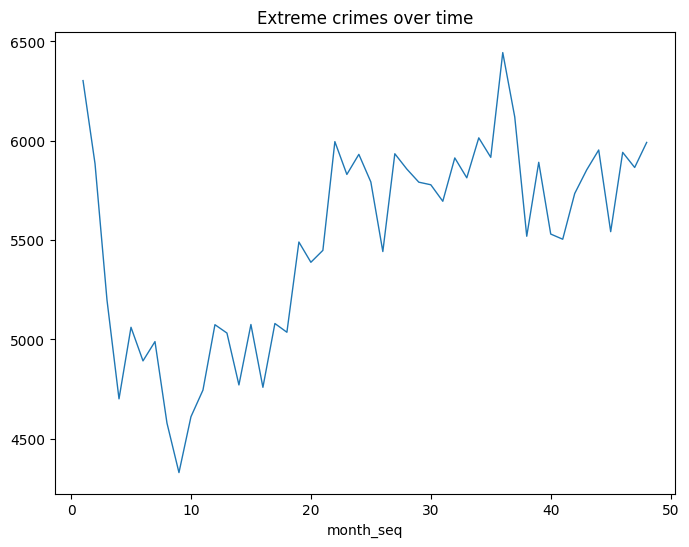

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))
ccmonth2wide.iloc[:,2].plot(linewidth = 1, ax = ax)
ax.set_title("Extreme crimes over time")

In [63]:
crimecomp['extreme_ind'] = (crimecomp['crm_cat2'] == 'extreme').astype(int)

# aggregate by month
ccweek = crimecomp.groupby('week_seq').agg(extreme=('extreme_ind','sum'), total= ('extreme_ind', 'size')).reset_index()
ccweek['p_extreme'] = ccweek['extreme'] / ccweek['total']
ccweek

ccweekarea = crimecomp.groupby(['AREA', 'week_seq']).agg(extreme = ('extreme_ind', 'sum'), total = ('extreme_ind', 'size')).reset_index()
ccweekarea['p_month_area'] = ccweekarea['extreme'] / ccweekarea['total']

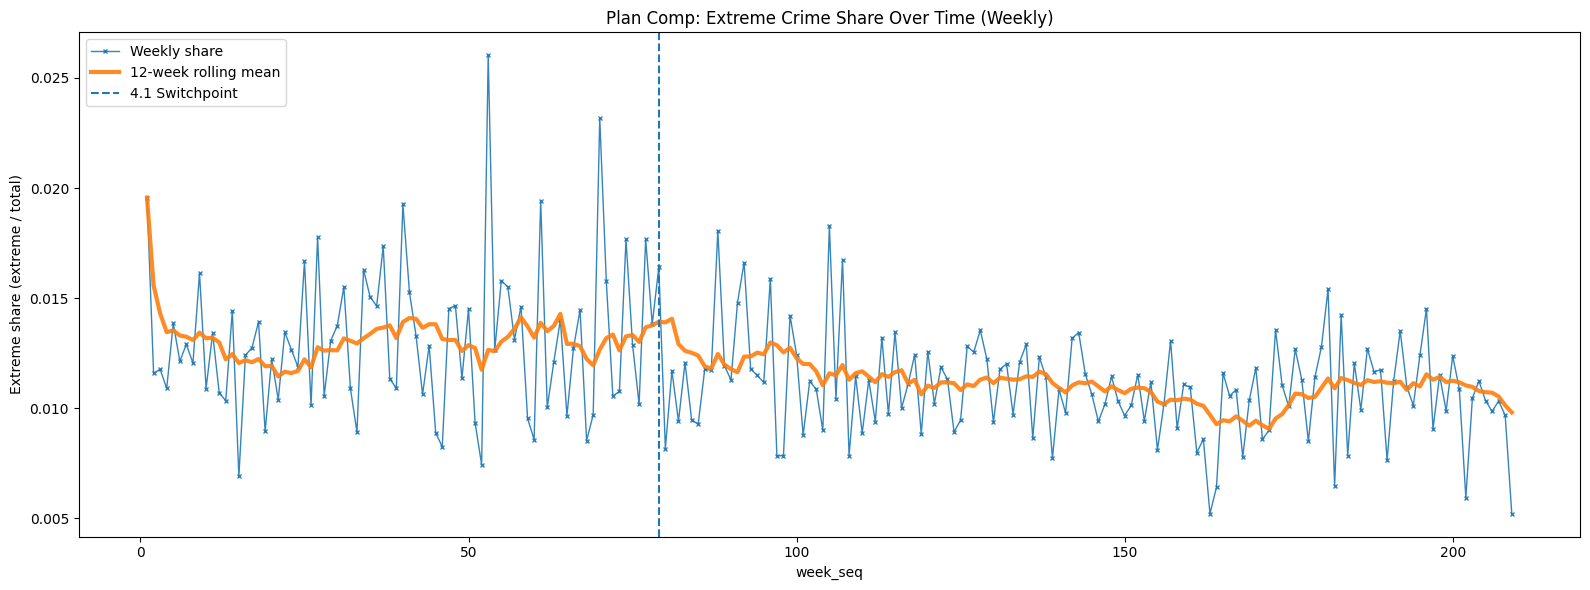

In [72]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(ccweek['week_seq'], ccweek['p_extreme'], linewidth=1, marker='x', markersize=3, alpha=0.9, label='Weekly share')
ax.plot(ccweek['week_seq'], ccweek['p_extreme'].rolling(12, min_periods=1).mean(), linewidth=3, alpha=0.9, label='12-week rolling mean')

ax.set_title('Plan Comp: Extreme Crime Share Over Time (Weekly)')
ax.set_xlabel('week_seq')
ax.set_ylabel('Extreme share (extreme / total)')
ax.axvline(79, linestyle = '--', label = '4.1 Switchpoint')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


Our $\hat p = \text{Prob}(\text{Crime is extreme})$ on this data set is simply the sample mean of `extreme_ind` which is binary data. We don't need to boot-strap, we can just apply binomial sampling to get our CI. Given the large sample size, this approach will be accurate and, more practically, speed up sampling by a significant amount. In addition, we can use the same methodology to figure out the difference in before and after our 79 week switchpoint.

1.18%
2.5%         =   1.15%
50% (median) =   1.18%
97.5%        =   1.20%


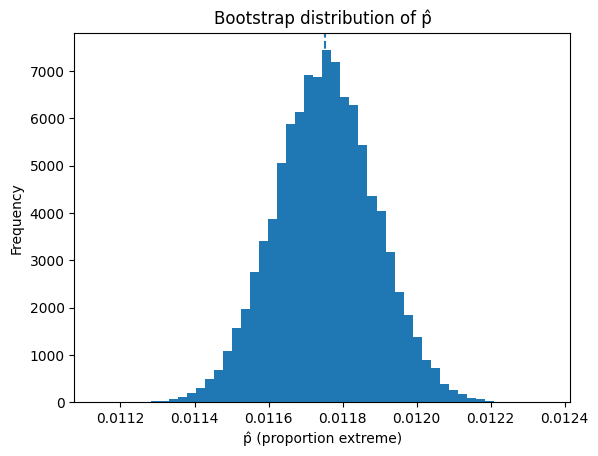

In [59]:
p_hat = crimecomp['extreme_ind'].mean()
print(f"{p_hat * 100:.2f}%")

n = len(crimecomp)

boot_p = np.random.binomial(n, p_hat, size=100000) / n

labels = ["2.5%", "50% (median)", "97.5%"]
values = np.percentile(boot_p, [2.5, 50, 97.5])

for lab, val in zip(labels, values):
    print(f"{lab:12s} = {val*100:6.2f}%")

plt.hist(boot_p, bins=50)
plt.axvline(p_hat, linestyle='--')
plt.xlabel("p̂ (proportion extreme)")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of p̂")
plt.show()

In [66]:
split = 79 # learned from analysis in 4.1, divided by average number of weeks per year

early = crimecomp[crimecomp['week_seq'] <= split]
late  = crimecomp[crimecomp['week_seq'] > split]

n_e = len(early)
n_l = len(late)


B = 10000

p_e = early['extreme_ind'].mean()
p_l = late['extreme_ind'].mean()
delta_hat = p_l - p_e

n_e = len(early)
n_l = len(late)

boot_delta = (
    np.random.binomial(n_l, p_l, size=B) / n_l
    - np.random.binomial(n_e, p_e, size=B) / n_e
)

labels = ["2.5%", "50% (median)", "97.5%"]
vals = np.percentile(boot_delta, [2.5, 50, 97.5])

print(f"{'Delta hat':12s} = {delta_hat*100:6.2f}%\n")

for lab, val in zip(labels, vals):
    print(f"{lab:12s} = {val*100:6.2f}%")



Delta hat    =  -0.22%

2.5%         =  -0.28%
50% (median) =  -0.22%
97.5%        =  -0.17%


Our data shows that after the switchpoint, the proportion of extreme crimes actually decreased, despite the total number of crimes increasing. There is an intuitive anecdotal explanation, which is that "true" criminals are not stopped by a quarantine, whereas more mundane crimes can happen between everyday citizens. However, our graph of absolute values of extreme crimes still showed a dip during the quarantine period. 

Extreme crime share was treated as a sample proportion rather than the more expensive boot-strapping. Confidence intervals were all computed using the normal approximation to the binomial, which is OK due to our large sample size.

#### 4.2.4 Next steps with extreme crimes

Our data set is large, but limited in a number of ways. Most of the columns describe attributes intrinsic to the crime event, rather than the context in which that crime occurred. In other words, we do not necessarily have the tools to **predict** or even **forecast** crime based on other variables. For example, weapon usage and MO are both directly linked to whether or not a crime is extreme, we don't know these attributes a priori of the extreme crime happening. 

Instead, we will mirror the approach from 4.1 and evaluate the crime trends over time, especially how the trends change over time and area. Our analysis will be descriptive rather than causal as we initially set out. 